# Recreación de las ondas Alven

Santiago Acosta

Vamos a recrear las ondas Alven y comparar los resultados con aquellos dados por PLUTO.

Para ello, vamos a utilizar y modificar el código dado por el profesor. 

__MÉTODO ELEGIDO:__ Runge-Kutta 2

In [1]:
import pyPLUTO as pp
import numpy as np
import matplotlib.pyplot as plt

# Definimos los parámetros
N, L, A = 256, 1., 0.1
B0 = rho0 = mu0 = 1.0


def create_system(CFL, t_max):
    # Parámetros por sistema
    vA = B0 / np.sqrt(mu0 * rho0)
    dx = L / N 
    dt = CFL * dx / vA
    NT = int(t_max / dt)
    ts = np.linspace(0.0, t_max, NT)
    
    # Malla y CI
    x = np.linspace(0., L, N, endpoint=False)
    dv = A * np.sin(2. * np.pi * x / L)
    dB = A * np.sin(2. * np.pi * x / L)
    
    #=========================
    # Definición del RK2
    
    # Deriv. espaciales
    def ddx(f, dx):
        return (np.roll(f, -1) - np.roll(f, 1)) / (2. * dx)
    
    # RHS
    def rhs(dv, dB, B0, rho0, dx):
        c = B0 / (mu0 * rho0)
        dv_t = c * ddx(dB, dx)
        dB_t = B0 * ddx(dv, dx)
        return dv_t, dB_t
    
    # Bucle temporal
    for pt in ts:
 
        # Etapa 1
        dv1, dB1 = rhs(dv, dB, B0, rho0, dx)
        dv_star = dv + dt*dv1
        dB_star = dB + dt*dB1
    
        # Etapa 2
        dv2, dB2 = rhs(dv_star, dB_star, B0, rho0, dx)
        dv += 0.5*dt*(dv1 + dv2)
        dB += 0.5*dt*(dB1 + dB2)

    return dv, dB
    

PyPLUTO version: 1.1.5   session: Jupyter notebook or qtconsole


Ahora revisamos lo que dan estos resultados

## Punto 5: comparación con PLUTO

Load: Load class initialized.


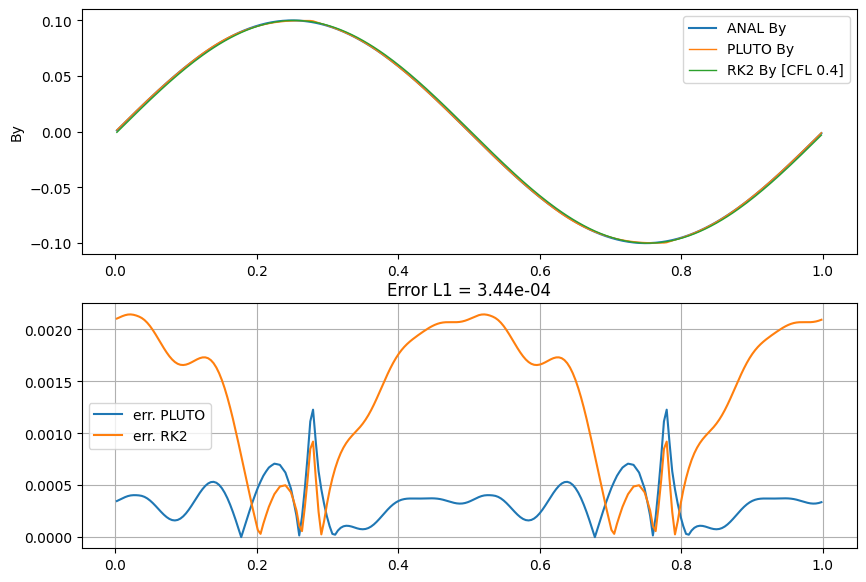

In [2]:
# Creamos nuestra propia simulación
dv08, dB08 = create_system(0.4, 10.)

# Cargamos lo encontrado en el pypluto
D = pp.Load(10, w_dir = "./")
x = D.x1 
By = D.Bx2 

# Creamos la solución analítica
t = D.ntime
A = 0.1 
By_ex = A * np.sin(2. * np.pi * (x-t))
Bz_ex = A * np.cos(2. * np.pi * (x-t))

# Creamos los plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(x, By_ex, label = "ANAL By", lw = 1.5)
ax1.plot(x, By, label = "PLUTO By", lw = 1.0)
ax1.plot(x, dB08, label = "RK2 By [CFL 0.4]", lw = 1.0)
plt.grid()

ax1.set_ylabel('By')
ax1.legend()

err = np.mean(np.abs(By - By_ex))
ax2.set_title(f"Error L1 = {err:.2e}")
ax2.plot(x, abs(By - By_ex), label = "err. PLUTO")
ax2.plot(x, abs(By - dB08), label = "err. RK2")
plt.legend()
plt.show()


En general, Runge-Kutta resulta ser mucho más inestable. Esto no sólo se ve en el error $L_1$ que siempre es mayor al de PLUTO, pero también en el hecho que, mientras PLUTO puede trabajar con $CFL > 0.5$ sin presentar inestabilidades numéricas, nuestro método por RK2 es inestable para $CFL > 0.5$. 

## Punto 1: revisar comportamiento temporal y velocidad $v_A$

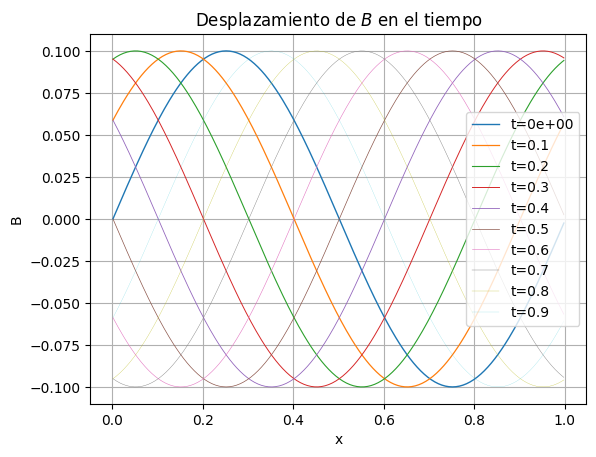

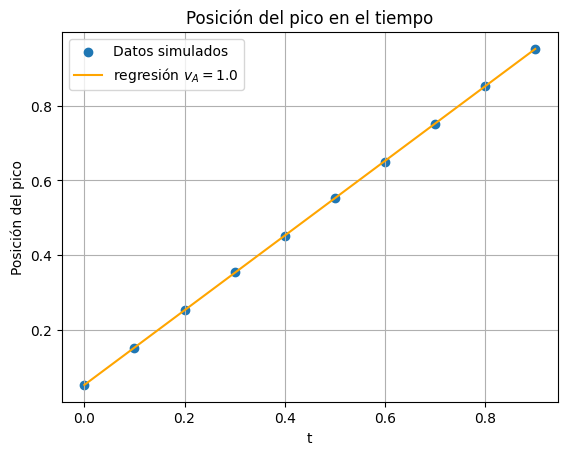

In [35]:
# Creamos las soluciones en todos estos tiempos
tiempos = [0.1*i for i in range(10)]
sol = [create_system(0.1, t)[1] for t in tiempos] # Guardamos la info de los picos


for B, t in zip(sol, tiempos):
    plt.plot(x, B, label = f"t={t:.1}", lw = 1.0 - t)  # Hacemos esto en el lw para poder ver mejor las cositas

plt.title(r"Desplazamiento de $B$ en el tiempo")
plt.ylabel(r"B")
plt.xlabel(r"x")
plt.legend()
plt.grid()
plt.show()

# Cálculo de los picos que tenemos (y organizamos para que todo esté más bonito)
peaks_index = sorted([np.argmax(s) for s in sol])

"""NOTA: aquí tenemos una suerte de simetría temporal, por lo que hacer este sort de los picos es irrelevante"""

# Encontramos la línea regresión
coeffs = np.polyfit(tiempos, x[peaks_index], 1)
slope, intercept = coeffs
y_fit = slope * np.array(tiempos) + intercept

# Graficamos la tendencia de los picos
plt.title("Posición del pico en el tiempo")
plt.scatter(tiempos, x[peaks_index], label = "Datos simulados")
plt.plot(tiempos, y_fit, label = rf"regresión $v_A = {slope}$", c = "orange")
plt.legend
plt.xlabel("t")
plt.ylabel("Posición del pico")
plt.legend()
plt.grid()

Podemos ver que, en efecto, el pico de $B$ se mueve a $v = v_A = 1.0$

# Punto 2: errores contra N

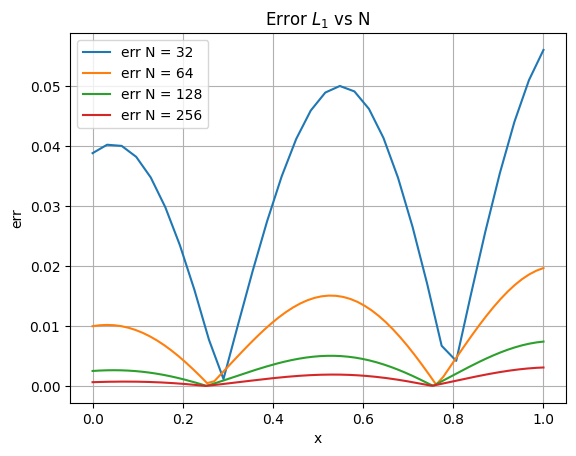

In [41]:
# Creamos la lista de Ns
Ns = [2**(5 + i) for i in range(4)]


for N in Ns:
    # Creamos nuestra propia simulación
    dv, dB = create_system(0.1, 10.)

    # Creamos la solución analítica
    x = np.linspace(0.0, 1.0, N)
    By = 0.1 * np.sin(2. * np.pi * (x-10.))

    # Error
    err = np.mean(np.abs(By - dB))

    plt.plot(x, abs(By - dB), label = f"err N = {N}")

    
plt.title(r"Error $L_1$ vs N")
plt.xlabel("x")
plt.ylabel("err")
plt.grid()
plt.legend()
plt.show()


En general, podemos ver que a medida que aumentamos $N$, mayor es la convergencia entre el resultado simulado y la solución analítica. También, no importa el $N$ que escojamos, el error $L_1$ crece a medida que simulamos regiones más alejadas del inicio, esto seguramente debido a las inestabilidades numéricas del método.

# Punto 3: estabilidad CFL

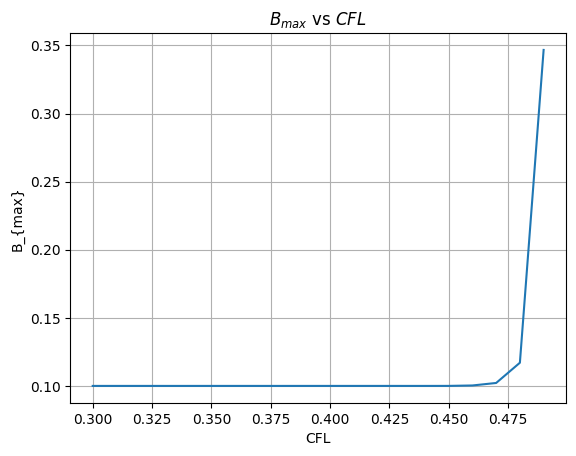

In [47]:
# Creamos la lista de Ns
CFLs = [0.3 + 0.01 * i for i in range(20)]

N = 256
maxes = list()
for CFL in CFLs:
    # Creamos nuestra propia simulación
    dv, dB = create_system(CFL, 10.)
    x = np.linspace(0.0, 1.0, 256)

    # Creamos un indicador de convergencia, en este caso, el valor máximo hallado
    maxes.append(np.max(dB))

    
plt.plot(CFLs, maxes)
plt.title(r"$B_{max}$ vs $CFL$")
plt.xlabel("CFL")
plt.ylabel(r"B_{max}")
plt.grid()

plt.show()

Podemos ver que, en general, con Runge-Kutta2 el sistema se comporta bien para valores de $CFL < 0.45$

# Punto 4: amortiguación

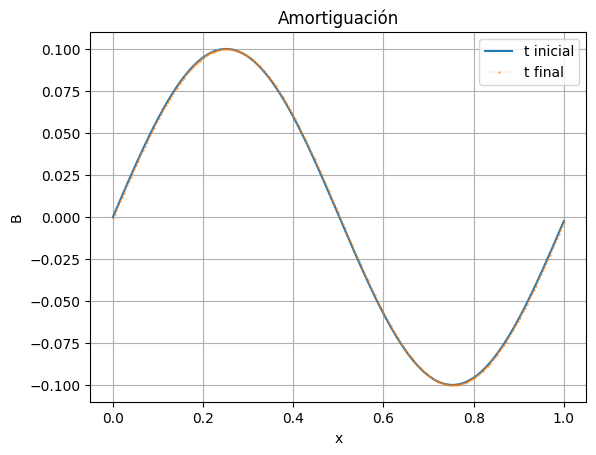

In [65]:
# Creamos nuestra propia simulación
dvi, dBi = create_system(0.4, 0.)
dvf, dBf = create_system(0.4, 10.)
N = 256
x = np.linspace(0.0, 1.0, 256)

plt.plot(x, dBi, label = f"t inicial")
plt.plot(x, dBf, label = f"t final", marker = '.', lw = 0.1, markersize=1.0)
plt.title("Amortiguación")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("B")
plt.show()


En general, usando RK2 no se ve un amortiguamiento. Quizás esta es la razón por la que se quería añadir artificialmente.